In [1]:
# =============================
# INSTALAÇÃO DAS BIBLIOTECAS
# =============================
!pip install networkx matplotlib python-louvain python-igraph leidenalg scipy pandas

# =============================
# IMPORTAÇÕES
# =============================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from community import community_louvain
from networkx.algorithms import community as nx_comm
import igraph as ig
import leidenalg

# =============================
# 1. CARREGAMENTO DA REDE TWITTER
# =============================
# O dataset 'twitter_combined.txt' deve estar na pasta 'data/'
G_TW = nx.read_edgelist("data/twitter_combined.txt", create_using=nx.Graph(), nodetype=int)

print("=== Estatísticas da Rede do twitter ===")
print("Número de nós:", G_TW.number_of_nodes())
print("Número de arestas:", G_TW.number_of_edges())
print("Grau médio:", round(sum(dict(G_TW.degree()).values()) / G_TW.number_of_nodes(), 2))

# Layout fixo para garantir consistência visual entre algoritmos
np.random.seed(42)
spring_pos = nx.spring_layout(G_TW, seed=42)

# =============================
# FUNÇÕES AUXILIARES
# =============================

def plot_communities(G, pos, partition, title, filename=None):
    """Gera visualização colorida por comunidade."""
    unique_comms = set(partition.values())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_comms)))
    node_colors = [colors[partition[node]] for node in G.nodes()]

    plt.figure(figsize=(12, 10))
    nx.draw_networkx(G, pos=pos, node_color=node_colors, node_size=10, with_labels=False)
    plt.title(title)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_metrics(G, communities, algorithm_name, execution_time):
    """Calcula métricas de desempenho das comunidades."""
    if isinstance(communities, dict):  # Ex: Louvain
        communities = [set([k for k, v in communities.items() if v == c])
                      for c in set(communities.values())]
    
    modularity = nx_comm.modularity(G, communities)
    sizes = [len(c) for c in communities]
    
    return {
        "Algoritmo": algorithm_name,
        "Tempo (s)": round(execution_time, 2),
        "Modularidade": round(modularity, 4),
        "Nº Comunidades": len(sizes),
        "Tamanho Médio": round(np.mean(sizes), 2),
        "Desvio Padrão": round(np.std(sizes), 2)
    }


=== Estatísticas da Rede do twitter ===
Número de nós: 81306
Número de arestas: 1342310
Grau médio: 33.02



=== Executando Louvain ===
{'Algoritmo': 'Louvain', 'Tempo (s)': 56.96, 'Modularidade': 0.8066, 'Nº Comunidades': 71, 'Tamanho Médio': 1145.15, 'Desvio Padrão': 1934.36}


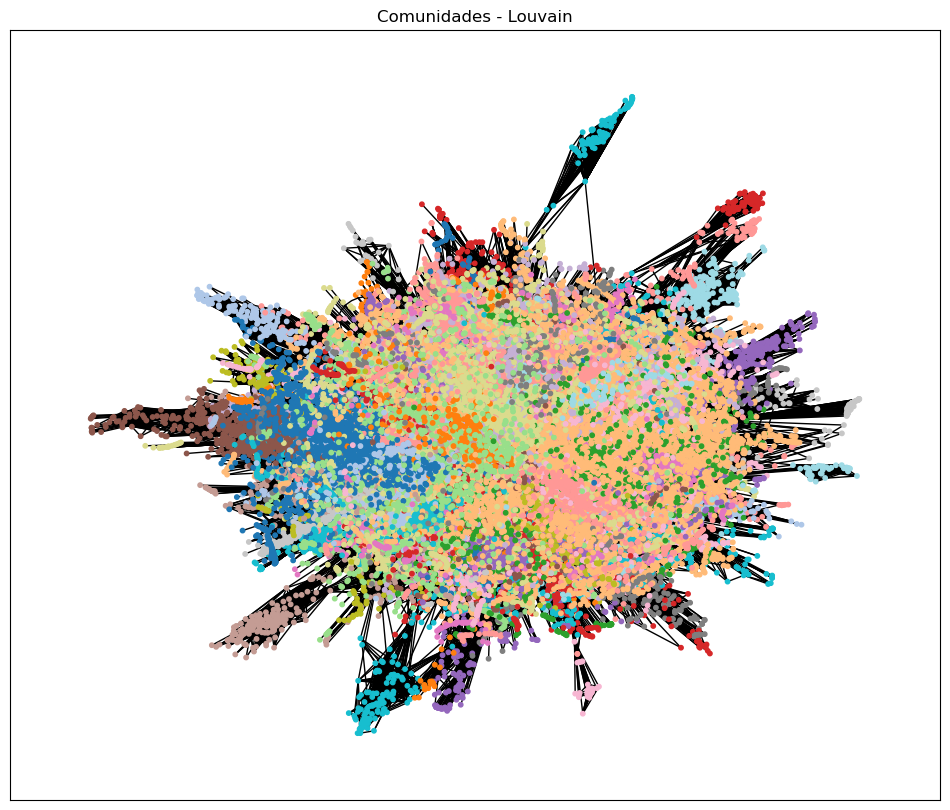

In [3]:
# =============================
# 2. LOOUVAIN
# =============================
print("\n=== Executando Louvain ===")
start = time.time()
partition_louvain = community_louvain.best_partition(G_TW)
louvain_time = time.time() - start
metrics_louvain = calculate_metrics(G_TW, partition_louvain, "Louvain", louvain_time)
print(metrics_louvain)
plot_communities(G_TW, spring_pos, partition_louvain, "Comunidades - Louvain", "twitter_louvain.png")


=== Executando Label Propagation ===
{'Algoritmo': 'Label Propagation', 'Tempo (s)': 42.88, 'Modularidade': 0.7562, 'Nº Comunidades': 897, 'Tamanho Médio': 90.64, 'Desvio Padrão': 615.96}


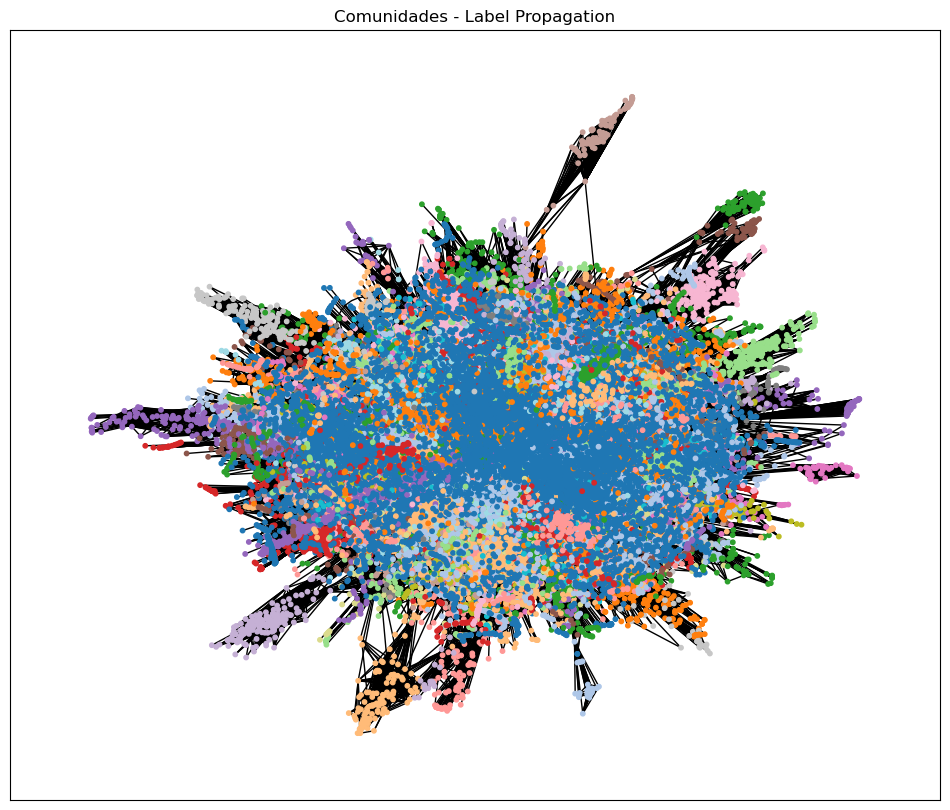

In [4]:
# =============================
# 3. LABEL PROPAGATION
# =============================
print("\n=== Executando Label Propagation ===")
start = time.time()
communities_lpa = list(nx_comm.label_propagation_communities(G_TW))
lpa_time = time.time() - start
partition_lpa = {node: i for i, comm in enumerate(communities_lpa) for node in comm}
metrics_lpa = calculate_metrics(G_TW, communities_lpa, "Label Propagation", lpa_time)
print(metrics_lpa)
plot_communities(G_TW, spring_pos, partition_lpa, "Comunidades - Label Propagation", "twitter_lpa.png")


=== Executando Leiden ===
{'Algoritmo': 'Leiden', 'Tempo (s)': 1.41, 'Modularidade': 0.8104, 'Nº Comunidades': 76, 'Tamanho Médio': 1069.82, 'Desvio Padrão': 1929.15}


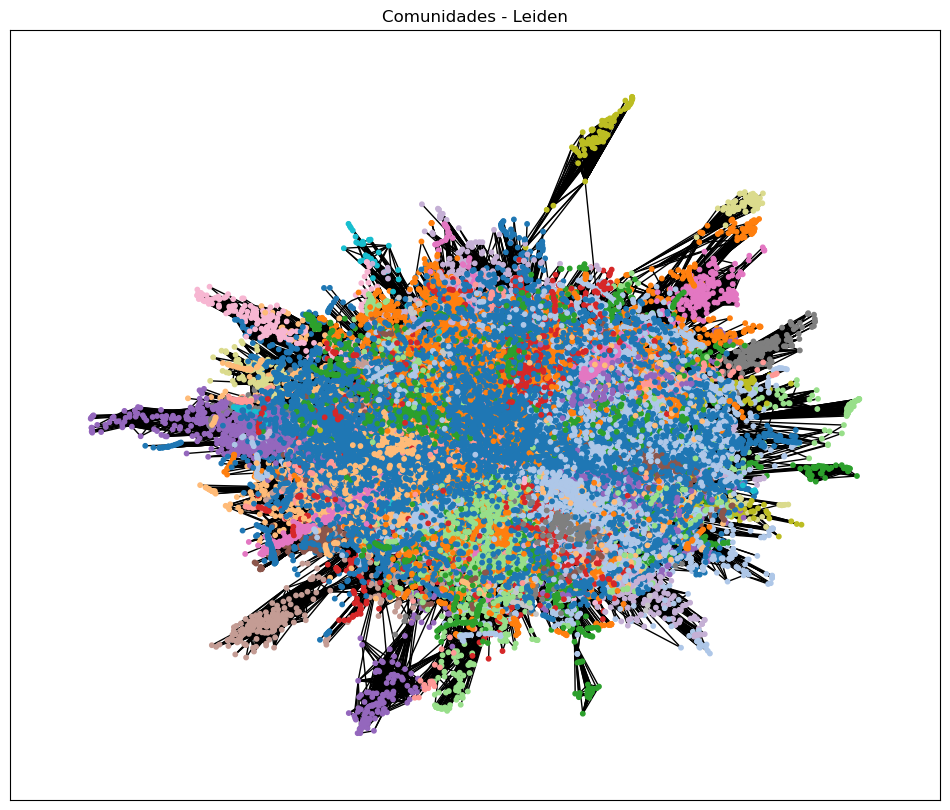

In [5]:
# =============================
# 4. LEIDEN
# =============================
print("\n=== Executando Leiden ===")
edges = list(G_TW.edges())
G_ig = ig.Graph.TupleList(edges, directed=False)
start = time.time()
partition_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
leiden_time = time.time() - start

# Conversão para dicionário
partition_leiden_nx = {int(G_ig.vs[node]["name"]): i for i, comm in enumerate(partition_leiden) for node in comm}
communities_leiden = [set([int(G_ig.vs[node]["name"]) for node in comm]) for comm in partition_leiden]
metrics_leiden = calculate_metrics(G_TW, communities_leiden, "Leiden", leiden_time)
print(metrics_leiden)
plot_communities(G_TW, spring_pos, partition_leiden_nx, "Comunidades - Leiden", "twitter_leiden.png")



=== Comparação Final ===
           Algoritmo  Tempo (s)  Modularidade  Nº Comunidades  Tamanho Médio  \
0            Louvain      56.96        0.8066              71        1145.15   
1  Label Propagation      42.88        0.7562             897          90.64   
2             Leiden       1.41        0.8104              76        1069.82   

   Desvio Padrão  
0        1934.36  
1         615.96  
2        1929.15  


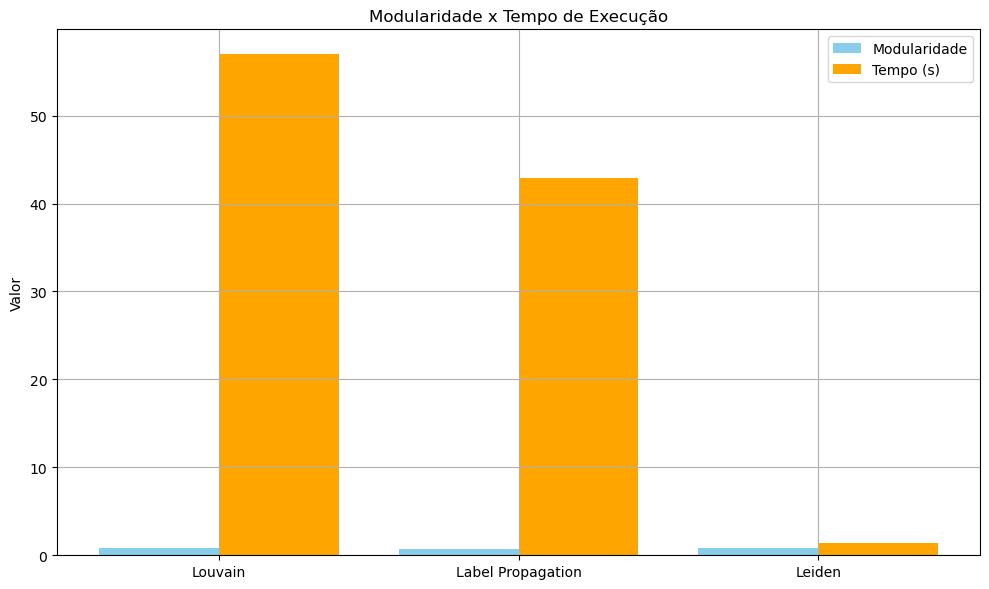

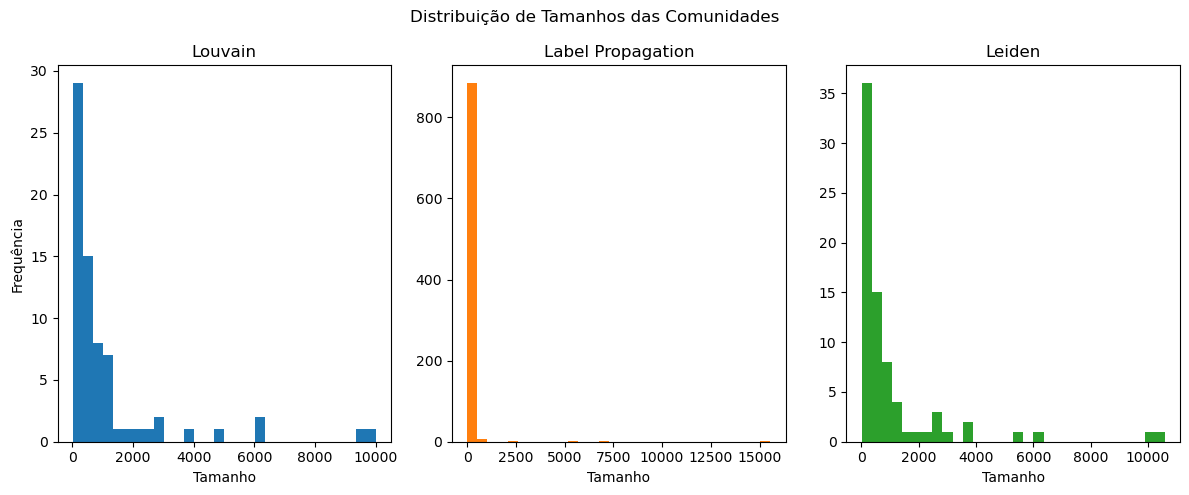

In [6]:
# =============================
# 5. COMPARAÇÃO FINAL
# =============================
print("\n=== Comparação Final ===")
results = pd.DataFrame([metrics_louvain, metrics_lpa, metrics_leiden])
print(results)

# Gráfico comparativo: Modularidade x Tempo
plt.figure(figsize=(10, 6))
x = range(len(results))
plt.bar(x, results["Modularidade"], width=0.4, label="Modularidade", color="skyblue")
plt.bar([i + 0.4 for i in x], results["Tempo (s)"], width=0.4, label="Tempo (s)", color="orange")
plt.xticks([i + 0.2 for i in x], results["Algoritmo"])
plt.ylabel("Valor")
plt.title("Modularidade x Tempo de Execução")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("twitter_comparacao_modularidade_tempo.png", dpi=300)
plt.show()

# Histograma de tamanhos das comunidades
plt.figure(figsize=(12, 5))
for i, (nome, part) in enumerate([
    ("Louvain", partition_louvain),
    ("Label Propagation", partition_lpa),
    ("Leiden", partition_leiden_nx)
]):
    sizes = [list(part.values()).count(c) for c in set(part.values())]
    plt.subplot(1, 3, i+1)
    plt.hist(sizes, bins=30, color=plt.cm.tab10(i))
    plt.title(nome)
    plt.xlabel("Tamanho")
    if i == 0:
        plt.ylabel("Frequência")
plt.suptitle("Distribuição de Tamanhos das Comunidades")
plt.tight_layout()
plt.savefig("twitter_distribuicao_comunidades.png", dpi=300)
plt.show()


1. Objetivo da análise
O objetivo deste experimento foi comparar o desempenho de três algoritmos de detecção de comunidades aplicados a uma rede real de grande porte — a rede Twitter, com mais de 81 mil nós e 1,3 milhão de arestas. Os algoritmos avaliados foram:

Louvain: baseado em otimização de modularidade.

Label Propagation: baseado em propagação de rótulos sem supervisão.

Leiden: uma extensão otimizada do Louvain.

OBS: Enquanto o Louvain é amplamente usado por seu equilíbrio entre qualidade e desempenho, o Leiden visa melhorar a qualidade das comunidades e evitar comunidades desconectadas. Já o Label Propagation é extremamente simples e rápido, mas pode ser instável em redes grandes.

Modularidade:

Leiden teve a maior modularidade (0.8104), o que indica que ele encontrou uma divisão com maior coesão interna nas comunidades.

Louvain também teve ótimo desempenho (0.8066).

Label Propagation teve a menor modularidade (0.7562), o que sugere comunidades menos bem definidas.

Tempo de execução:

Leiden foi drasticamente mais rápido (apenas 1.41s), mostrando alta escalabilidade.

Louvain foi o mais lento (56.96s), o que pode ser um problema em redes ainda maiores.

Label Propagation foi intermediário (42.88s), mas ainda mais lento que Leiden, apesar de seu algoritmo ser mais simples.

Número de Comunidades e Tamanho Médio:

Label Propagation gerou muitas comunidades pequenas (897), o que indica potencial superfragmentação da rede.

Louvain e Leiden detectaram números mais realistas de comunidades (71 e 76), o que condiz com a estrutura esperada de uma rede social.

Ou seja:

Leiden é o melhor algoritmo para redes grandes: é mais rápido que todos e com melhor qualidade de particionamento.

Louvain ainda é robusto, mas é mais lento.

Label Propagation é mais instável, e tende a criar muitas comunidades pequenas demais.

Comparação entre as redes Facebook e Twitter:

Facebook (4039 nós):
Leiden foi o melhor (modularidade 0.8356, tempo 0.04s).

Louvain também teve ótima modularidade (0.8349), mas foi mais lento (1.44s).

Label Propagation teve desempenho significativamente inferior (modularidade 0.7368).

Twitter (81306 nós):
Leiden novamente se destacou: rápido (1.41s) e com maior modularidade (0.8104).

Louvain foi o mais lento (56.96s).

Label Propagation novamente produziu comunidades muito pequenas, o que prejudica a análise.

